## Visual Geomtry Group
It is the research group that works on vision and imaging. They developed VGG16 and VGG19 models that won the ImageNet competition. ImageNet is a competition/visual database that started with 1 million images with 1,000 categories(14 million accross 20,000 categories now). VGG16 and VGG19 are the first models to use convolution neural networks. These models are available in keras. VGG16 is a 5 chunks model with 16 layers that have trainable parameters.
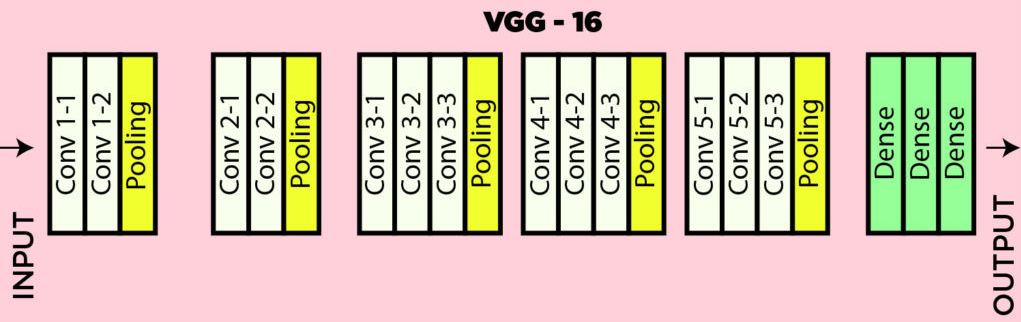

The chunks here are not con-pol but they are con-con-pol and con-con-con-pol. The initial con-con-pol help us find big features(like big lines and curves), the later con-con-con-pol layers help find more granular features(like small lines). As the catogories increase we might need to increase the number of chunks.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

In [11]:
vgg = tf.keras.applications.vgg16.VGG16()

#Trained models are made up of 2 things - weights and architecture
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [12]:
# The none above to the input layer indicates that any number of inputs can be given at a time for prediction. 
# This model is trained with only 1.38 million parameters for the million images.
# For all convolution layers padding is set to 'same', hence no image size reduction in convolution layers
# As we can see above the final predictions dense(output) layer has 1000 categories.
# VGG16 paper - https://arxiv.org/pdf/1409.1556.pdf

In [13]:
# When a model is saved weights and the architecture are saved
print(len(vgg.get_weights()))
vgg.to_json()

32


'{"class_name": "Functional", "config": {"name": "vgg16", "layers": [{"class_name": "InputLayer", "config": {"batch_input_shape": [null, 224, 224, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_2"}, "name": "input_2", "inbound_nodes": []}, {"class_name": "Conv2D", "config": {"name": "block1_conv1", "trainable": true, "dtype": "float32", "filters": 64, "kernel_size": [3, 3], "strides": [1, 1], "padding": "same", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"class_name": "GlorotUniform", "config": {"seed": null}}, "bias_initializer": {"class_name": "Zeros", "config": {}}, "kernel_regularizer": null, "bias_regularizer": null, "activity_regularizer": null, "kernel_constraint": null, "bias_constraint": null}, "name": "block1_conv1", "inbound_nodes": [[["input_2", 0, 0, {}]]]}, {"class_name": "Conv2D", "config": {"name": "block1_conv2", "trainable": true, "dtype": "float32", "fil

In [17]:
print(vgg.output_shape)
# Categories that the model can predict
catg = np.ones(shape=(1, 1000))
categories = [c[1] for c in tf.keras.applications.vgg16.decode_predictions(catg, top=1000)[0]]
np.random.choice(categories)

(None, 1000)


'hog'

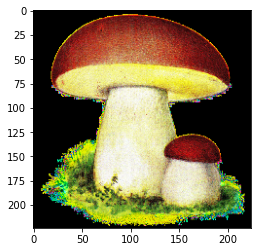

In [20]:
image = cv2.imread("bolete.png")
image = cv2.resize(image, (224, 224))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


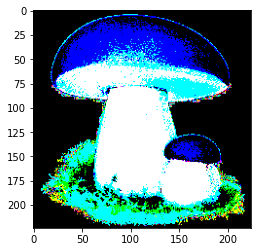

In [21]:
# Vgg uses standard scaling - (x - xmean)/std, not the min-max scaling we used for MNIST
# There fore these values can go negative too
pre_image = tf.keras.applications.vgg16.preprocess_input(image)
plt.imshow(pre_image)

In [46]:
pre_image.shape
pre_image = np.expand_dims(pre_image, 0)
pre_image.shape

(1, 224, 224, 3)

In [51]:
print(vgg.output_shape)
result = vgg.predict(pre_image)
print(result.shape)
np.argmax(result)
# Since input is one image, output is one row of 1000 probabilities, if we give n inputs then nX1000 probabilities
# will be in the output

(None, 1000)
1/1 [==============================] - 0s 183ms/step
(1, 1000)


997

In [53]:
tf.keras.applications.vgg16.decode_predictions(result, top=10)

[[('n13054560', 'bolete', 0.746816),
  ('n07734744', 'mushroom', 0.10650752),
  ('n04259630', 'sombrero', 0.066063754),
  ('n12998815', 'agaric', 0.06552576),
  ('n03637318', 'lampshade', 0.0065999045),
  ('n04380533', 'table_lamp', 0.0024662984),
  ('n13052670', 'hen-of-the-woods', 0.0021490667),
  ('n04277352', 'spindle', 0.0008237393),
  ('n13040303', 'stinkhorn', 0.00055866997),
  ('n13037406', 'gyromitra', 0.00047643465)]]

In [54]:
def vgg_predict(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224,224))
    image = tf.keras.applications.vgg16.preprocess_input(image)
    image = np.expand_dims(image, 0)
    result = vgg.predict(image)
    return image[0], result

1/1 [==============================] - 0s 340ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[[('n02108551', 'Tibetan_mastiff', 0.9379237),
  ('n02111277', 'Newfoundland', 0.02380993),
  ('n02105056', 'groenendael', 0.00986222),
  ('n02101006', 'Gordon_setter', 0.008769089),
  ('n02099267', 'flat-coated_retriever', 0.0075052213)]]

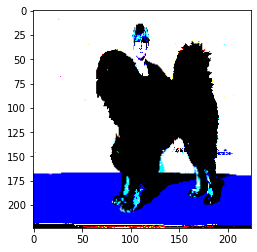

In [55]:
image, result = vgg_predict("tibetan_mastiff.jpg")
plt.imshow(image)
tf.keras.applications.vgg16.decode_predictions(result, top=5)